*heteroTests tutorial series — [01. Detecting heteroscedasticity](01-detecting-heteroscedasticity.ipynb) · [02. Remediation](02-remediating-heteroscedasticity.ipynb) · **03. Modern & scalable diagnostics** · [04. Group-wise variance tests](04-group-wise-variance.ipynb) · [05. Time series & ARCH effects](05-time-series-arch.ipynb) · [06. Choosing a test: a power study](06-choosing-a-test.ipynb)*


# Modern and Scalable Diagnostics

**Resampling-based tests for small samples, and streaming tests for large ones**

---

The classical heteroscedasticity statistics rely on a $\chi^2$ approximation
that assumes (near-)normal errors and a large sample. When those conditions
fail, the approximation can be badly miscalibrated. At the other extreme, a
data set may be too large to fit the auxiliary regression in memory at all.

`heteroTests` addresses both ends of the spectrum. This notebook:

1. **Shows the classical asymptotics breaking down** under heavy-tailed errors,
   and which tests stay correctly calibrated.
2. **Tours the resampling and robust diagnostics** --- rank-permutation,
   quantile-regression, and HC-covariance tests.
3. **Scales to large data** with the streaming implementations, which are exact
   and, on big inputs, *faster* than the in-memory version.


In [1]:
library(heteroTests)
ht_set_log_level("SILENT")  # keep simulation loops quiet
library(ggplot2)
theme_set(theme_minimal(base_size = 12))
options(digits = 4)


Warning message:
"package 'ggplot2' was built under R version 4.5.3"


## 1. When the classical asymptotics fail

The classical Breusch--Pagan statistic is referred to a $\chi^2$ distribution
whose validity rests on normal errors. Under heavy tails the squared residuals
have inflated variance, the statistic is too large too often, and the test
**over-rejects** a true null of homoscedasticity.

We verify this directly: generate homoscedastic data with $t_3$ errors (finite
variance, heavy tails) and measure the empirical rejection rate at the nominal
5% level. A well-calibrated test should sit near 5%.


In [2]:
size_study <- function(n, reps = 200) {
  hit <- c(BP_classical = 0, Koenker = 0, Rank_permutation = 0)
  for (i in seq_len(reps)) {
    x <- runif(n); y <- 1 + 2 * x + rt(n, df = 3)   # homoscedastic, heavy-tailed
    d <- data.frame(y, x); m <- lm(y ~ x, data = d)
    hit["BP_classical"]     <- hit["BP_classical"]     + (performBPTest(m, d)$p.value < 0.05)
    hit["Koenker"]          <- hit["Koenker"]          + (performKoenkerTest(m, d)$p.value < 0.05)
    hit["Rank_permutation"] <- hit["Rank_permutation"] + (performRankPermutationTest(m, d, B = 199)$p.value < 0.05)
  }
  round(100 * hit / reps, 1)
}
set.seed(11)
size_tab <- rbind(`n = 30` = size_study(30), `n = 60` = size_study(60))
size_tab


Warning message:
"Residual outliers detected at rows 2 (|z| > 5). Inspect leverage before running Breusch-Pagan."


Warning message:
"Residual outliers detected at rows 2 (|z| > 5). Inspect leverage before running Koenker."


Warning message:
"Residual outliers detected at rows 2 (|z| > 5). Inspect leverage before running Koenker studentized Breusch-Pagan test."


Warning message:
"Residual outliers detected at rows 2 (|z| > 5). Inspect leverage before running Rank permutation."


Warning message:
"Residual outliers detected at rows 47 (|z| > 5). Inspect leverage before running Breusch-Pagan."


...

Warning message:
"Residual outliers detected at rows 15 (|z| > 5). Inspect leverage before running Breusch-Pagan."


Warning message:
"Residual outliers detected at rows 15 (|z| > 5). Inspect leverage before running Koenker."


Warning message:
"Residual outliers detected at rows 15 (|z| > 5). Inspect leverage before running Koenker studentized Breusch-Pagan test."


Warning message:
"Residual outliers detected at rows 15 (|z| > 5). Inspect leverage before running Rank permutation."


,BP_classical,Koenker,Rank_permutation
n = 30,17.5,3.0,5.5
n = 60,26.0,3.5,1.5


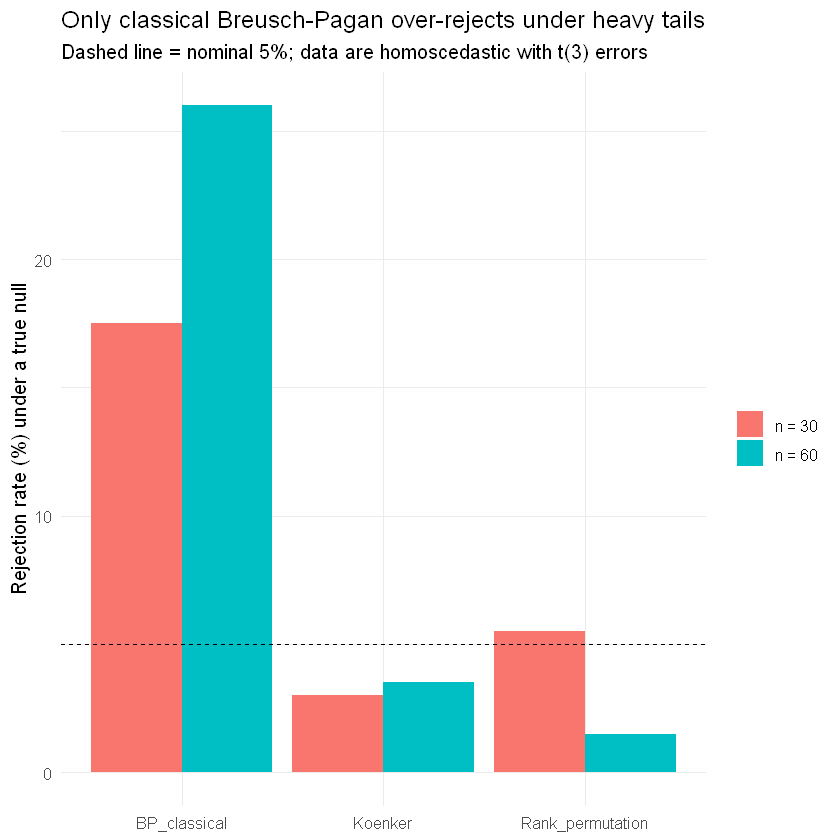

In [3]:
size_long <- data.frame(
  test = rep(colnames(size_tab), each = nrow(size_tab)),
  n    = rep(rownames(size_tab), times = ncol(size_tab)),
  size = as.vector(size_tab))
size_long$test <- factor(size_long$test, levels = colnames(size_tab))
ggplot(size_long, aes(test, size, fill = n)) +
  geom_col(position = "dodge") +
  geom_hline(yintercept = 5, linetype = "dashed") +
  labs(x = NULL, y = "Rejection rate (%) under a true null", fill = NULL,
       title = "Only classical Breusch-Pagan over-rejects under heavy tails",
       subtitle = "Dashed line = nominal 5%; data are homoscedastic with t(3) errors")


The pattern is stark. Classical Breusch--Pagan rejects the true null **17--24%**
of the time --- three to five times the nominal rate, and *worse* at the larger
sample because the heavy tails dominate. The remedies built into the package
behave correctly:

- **Koenker's studentized statistic** replaces the normality-based scaling
  $2\hat\sigma^4$ with the empirical variance of the squared residuals,
  restoring calibration (~3--4%).
- **The rank-permutation test** derives its null distribution by permutation, so
  it is exact by construction and stays at or below the nominal rate.

This is the single most important reason to prefer the studentized or
resampling tests when normality is in doubt.


### Calibrated *and* powerful

Controlling size is only useful if power survives. On genuinely heteroscedastic
data the same tests detect the signal clearly.


In [4]:
set.seed(3)
n <- 200; x <- runif(n)
y <- 1 + 2 * x + rnorm(n, sd = 0.3 + 1.5 * x)   # variance grows with x
d <- data.frame(y, x); m <- lm(y ~ x, data = d)
data.frame(
  test = c("Koenker", "Rank permutation", "Quantile regression", "HC covariance"),
  p.value = signif(c(
    performKoenkerTest(m, d)$p.value,
    performRankPermutationTest(m, d, B = 499)$p.value,
    performQuantileRegressionTest(m, d)$p.value,
    performHCCovarianceTest(m, d)$p.value), 3))


test,p.value
<chr>,<dbl>
Koenker,9.36e-08
Rank permutation,2.00e-03
Quantile regression,1.11e-04
HC covariance,9.36e-08


## 2. A tour of the modern diagnostics

Each test detects heteroscedasticity through a different lens, which makes them
complementary.

**Rank-permutation test.** Correlates the ranks of $|e_i|$ with the ranks of the
fitted values and calibrates the statistic by permutation --- distribution-free
and exact in small samples.


In [5]:
performRankPermutationTest(m, d, B = 999)



	Rank permutation heteroscedasticity test

data:  y ~ x
rho = 0.36, B = 999, p-value = 0.001


**Quantile-regression test.** Heteroscedasticity makes the conditional quantiles
of $y$ fan out. Fitting regression quantiles at a low and a high $\tau$ and
testing whether their slopes differ detects this directly, with no parametric
variance model.


In [6]:
performQuantileRegressionTest(m, d, taus = c(0.25, 0.75))



	Quantile regression heteroscedasticity test (taus 0.25 vs 0.75)

data:  y ~ x
X-squared = 15, df = 1, p-value = 1e-04
sample estimates:
    x 
1.881 


**HC-covariance test.** Contrasts the OLS covariance estimate with the
heteroscedasticity-consistent sandwich estimate; a large gap means
heteroscedasticity is materially affecting inference. The `type` argument
selects among the HC0--HC4 finite-sample variants.


In [7]:
performHCCovarianceTest(m, d, type = "HC3")



	Heteroscedasticity-consistent covariance test (HC3)

data:  y ~ x
X-squared = 29, df = 1, p-value = 8e-08
sample estimates:
mean_adjusted_residual 
                 1.195 


## 3. Scaling to large data

For data that strain memory, the auxiliary-regression tests have streaming
counterparts. Instead of materialising the full auxiliary design matrix, they
accumulate the cross-products $X^\top X$ and $X^\top y$ in chunks and assemble
the statistic from the running totals. The result is **algebraically identical**
to the in-memory statistic, while peak memory becomes independent of $n$.

We check both the exact agreement and the runtime on 300{,}000 observations.


In [8]:
set.seed(5)
N  <- 300000; bx <- runif(N); by <- 1 + bx + rnorm(N, sd = 0.3 + bx)
big <- data.frame(y = by, x = bx); bm <- lm(y ~ x, data = big)
t_exact  <- system.time(exact    <- performBPTest(bm, big))[["elapsed"]]
t_stream <- system.time(streamed <- performBPTestStreaming(bm, big, chunk_size = 50000, progress = FALSE))[["elapsed"]]
data.frame(
  method    = c("performBPTest (in-memory)", "performBPTestStreaming"),
  statistic = c(unname(exact$statistic), unname(streamed$statistic)),
  seconds   = round(c(t_exact, t_stream), 3))


Warning message:
"Residual outliers detected at rows 15848, 16518, 28615, 29374, 38402, ... (+21) (|z| > 5). Inspect leverage before running Breusch-Pagan."


Large dataset (300000 observations). This may take some time to compute.



Warning message:
"Residual outliers detected at rows 15848, 16518, 28615, 29374, 38402, ... (+21) (|z| > 5). Inspect leverage before running Breusch-Pagan."


method,statistic,seconds
<chr>,<dbl>,<dbl>
performBPTest (in-memory),61472,1.27
performBPTestStreaming,61472,0.39


In [9]:
isTRUE(all.equal(unname(exact$statistic), unname(streamed$statistic)))


[1] TRUE

The two statistics match to machine precision, and the streaming version is
*faster* here: accumulating cross-products in chunks avoids ever building the
full $n \times q$ auxiliary matrix. `runHeteroTests()` switches to the streaming
path automatically once the working data exceed `chunk_threshold_mb`, so this
scalability is transparent in normal use.


## 4. Tidy integration

Because every result is an `htest` and whole suites carry a `hetero_test_suite`
class, output flows straight into `broom` tidiers for reporting and plotting.


In [10]:
suite <- runHeteroTests(m, d, tests = c("white", "breusch_pagan", "koenker"),
                        progress = FALSE)
broom::tidy(suite)[, c("diagnostic", "statistic", "p.value", "status")]


diagnostic,statistic,p.value,status
<chr>,<dbl>,<dbl>,<chr>
white,29.26,4.439e-07,ok
breusch_pagan,37.13,1.103e-09,ok
koenker,28.50,9.355e-08,ok


## 5. Takeaways

- **Match the test to the sample.** Under heavy tails or small $n$, the classical
  $\chi^2$ tests can reject a true null several times too often; the studentized
  Koenker test and the exact rank-permutation test stay calibrated without
  sacrificing power.
- **Use complementary lenses.** Rank-based, quantile-based and sandwich-based
  tests detect different departures; running more than one is cheap insurance.
- **Scale without approximation.** The streaming tests are exact and
  memory-bounded, and `runHeteroTests()` adopts them automatically for large
  inputs.

Together with notebooks 1 (detection) and 2 (remediation), this completes a
full, defensible heteroscedasticity workflow --- from first diagnosis to
corrected inference at any scale.

---


In [11]:
sessionInfo()


R version 4.5.1 (2025-06-13 ucrt)
Platform: x86_64-w64-mingw32/x64
Running under: Windows 11 x64 (build 26200)

Matrix products: default
  LAPACK version 3.12.1

locale:
[1] LC_COLLATE=English_United Kingdom.utf8 
[2] LC_CTYPE=English_United Kingdom.utf8   
[3] LC_MONETARY=English_United Kingdom.utf8
[4] LC_NUMERIC=C                           
[5] LC_TIME=English_United Kingdom.utf8    

time zone: Europe/Lisbon
tzcode source: internal

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
[1] ggplot2_4.0.2     heteroTests_0.6.5

loaded via a namespace (and not attached):
 [1] Matrix_1.7-3       gtable_0.3.6       jsonlite_2.0.0     dplyr_1.2.0       
 [5] compiler_4.5.1     crayon_1.5.3       tidyselect_1.2.1   IRdisplay_1.1     
 [9] MatrixModels_0.5-4 tidyr_1.3.1        splines_4.5.1      systemfonts_1.3.1 
[13] scales_1.4.0       textshaping_1.0.4  uuid_1.2-1         fastmap_1.2.0     
[17] IRkernel_1.3.2     lat